In [1]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
from sklearn.linear_model import LinearRegression  # For linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics
from sklearn.model_selection import train_test_split  # For splitting data into training and test sets
import lightgbm as lgb  # For LightGBM model
import xgboost as xgb  # For XGBoost model

In [15]:

# Load the COVID-19 dataset for India
df = pd.read_csv("covid_19_india.csv")

# Convert the 'Date' column to datetime format for better handling of time series data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Group the data by 'Date' and sum the 'Confirmed', 'Cured', and 'Deaths' columns
# This aggregates the data to ensure that each date has a single entry
df = df.groupby('Date')[['Confirmed', 'Cured', 'Deaths']].sum().reset_index()

# Calculate daily new confirmed cases by taking the difference between consecutive days
df['New_Cases'] = df['Confirmed'].diff().fillna(0)

# Replace negative differences with zero to avoid counting negative new cases
df['New_Cases'] = df['New_Cases'].apply(lambda x: x if x > 0 else 0)

# Create lag features to provide the model with historical data
# Lag_1: New cases from the previous day
df['Lag_1'] = df['New_Cases'].shift(1)
# Lag_7: New cases from one week ago
df['Lag_7'] = df['New_Cases'].shift(7)
# Lag_14: New cases from two weeks ago
df['Lag_14'] = df['New_Cases'].shift(14)

# Drop rows with NaN values that arise from the lagging process
df = df.dropna()

C:\Users\Sumi\AppData\Local\Temp\ipykernel_5116\3756741931.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [16]:

# Define features (X) and target variable (y)
X = df[['Lag_1', 'Lag_7', 'Lag_14']]  # Features: lagged new cases
y = df['New_Cases']  # Target: new cases

# Store the date information for later use
dates = df['Date']

In [17]:

# Split the data into training and testing sets
# 20% of the data will be used for testing, and the order of the data will be preserved (no shuffling)
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, shuffle=False
)


In [18]:

# === 1. Linear Regression ===
# Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Predict new cases using the Linear Regression model
y_pred_lr = lr_model.predict(X_test)


In [19]:
# === Evaluation ===
# Define a function to evaluate the model's performance using various metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)  # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Root Mean Squared Error
    r2 = r2_score(y_true, y_pred)  # R-squared score
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }
# Evaluate all models and store the results
results = [
    evaluate_model(y_test, y_pred_lr, "Linear Regression"),
]

In [20]:
# Convert results into a DataFrame for better visualization
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison:\n", results_df)



📊 Model Comparison:
                Model      MAE      RMSE  R2 Score
0  Linear Regression  9571.78  15091.02    0.9868


C:\Users\Sumi\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


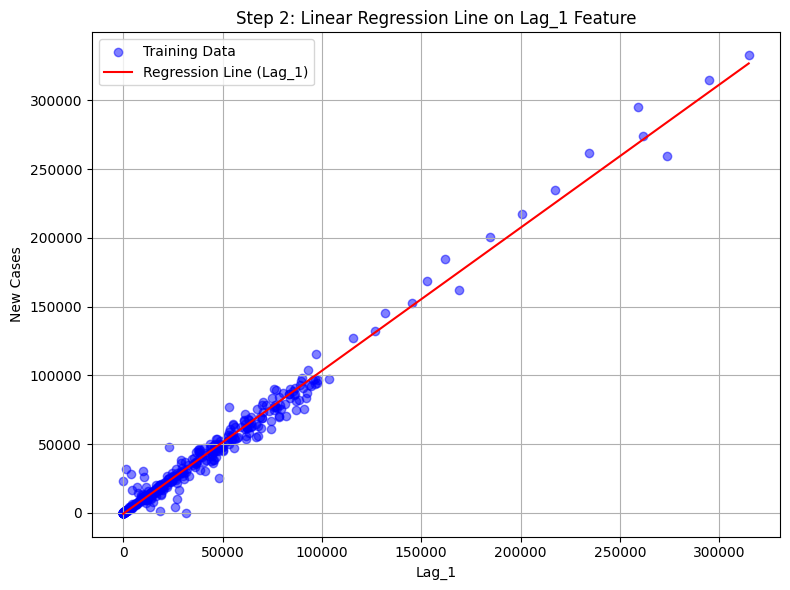

In [24]:
# === Step 2: Show the Linear Regression line being made (using one feature for visualization) ===
# We'll just use Lag_1 to illustrate the regression line visually
plt.figure(figsize=(8, 6))
plt.scatter(X_train['Lag_1'], y_train, alpha=0.5, label='Training Data', color='blue')

# Fit a temporary model on just Lag_1 for line visualization
temp_model = LinearRegression()
temp_model.fit(X_train[['Lag_1']], y_train)
line_x = np.linspace(X_train['Lag_1'].min(), X_train['Lag_1'].max(), 100)
line_y = temp_model.predict(line_x.reshape(-1, 1))

plt.plot(line_x, line_y, color='red', label='Regression Line (Lag_1)')
plt.xlabel('Lag_1')
plt.ylabel('New Cases')
plt.title('Step 2: Linear Regression Line on Lag_1 Feature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

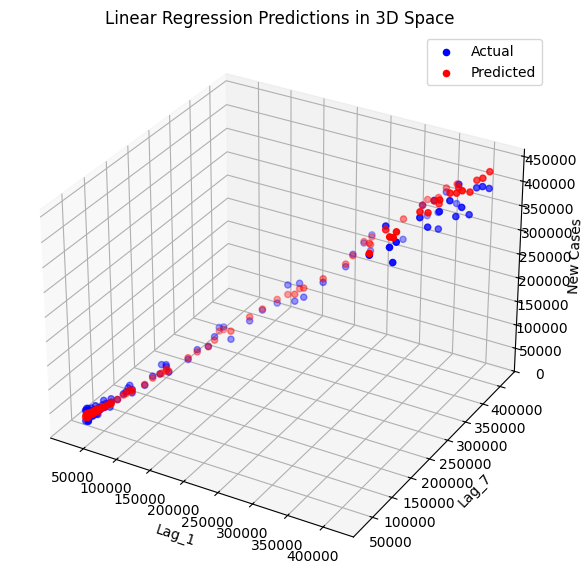

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test['Lag_1'], X_test['Lag_7'], y_test, color='blue', label='Actual')
ax.scatter(X_test['Lag_1'], X_test['Lag_7'], y_pred_lr, color='red', label='Predicted')

ax.set_xlabel('Lag_1')
ax.set_ylabel('Lag_7')
ax.set_zlabel('New Cases')
plt.title('Linear Regression Predictions in 3D Space')
plt.legend()
plt.show()


In [25]:
# === Step 3: Fit the actual model ===
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

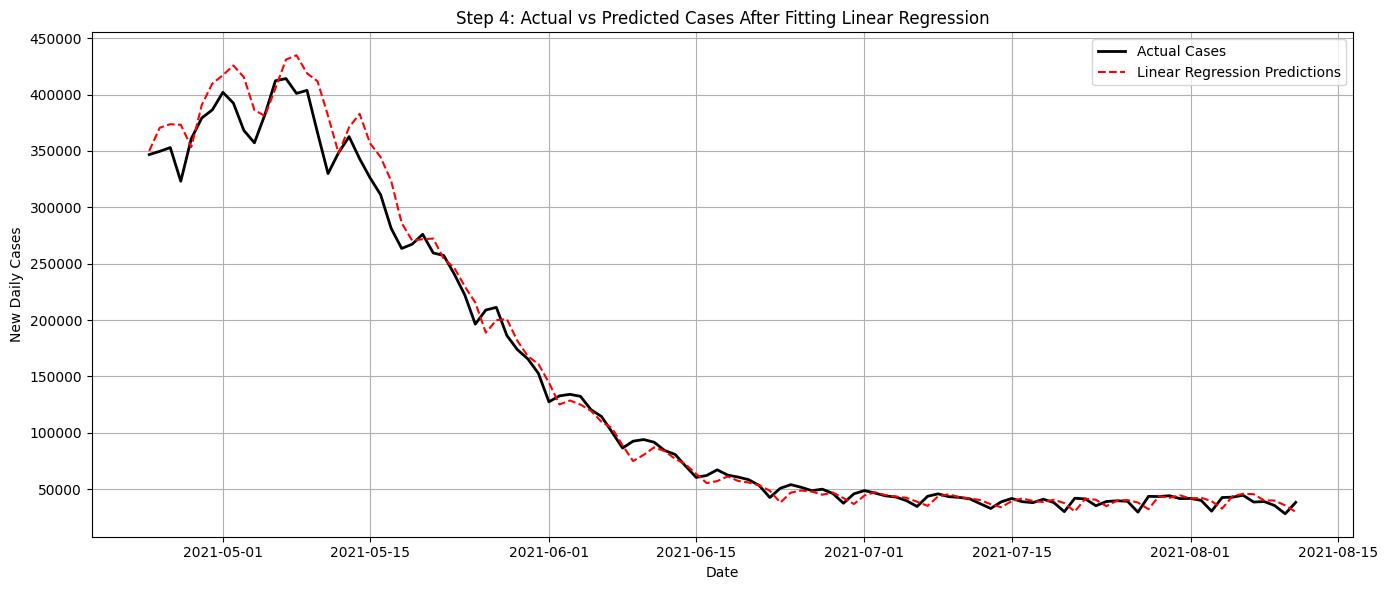

In [26]:
# === Step 4: Show how the model performs on the test set ===
# We'll plot actual vs predicted using the test set
y_pred_lr = lr_model.predict(X_test)

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual Cases", color='black', linewidth=2)
plt.plot(dates_test, y_pred_lr, label="Linear Regression Predictions", linestyle='--', color='red')
plt.xlabel("Date")
plt.ylabel("New Daily Cases")
plt.title("Step 4: Actual vs Predicted Cases After Fitting Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
